In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random

# notebook code2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
#from temporal_analysis import run_temporal_analysis
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.spatial.distance import jensenshannon
import warnings
warnings.filterwarnings('ignore')



Processando dados...
Vocabulário: 22 comportamentos únicos
Total de sequências: 11096
Espécies: 13

Iniciando treinamento...
Epoch [1/20], Loss: 1.0779
Epoch [2/20], Loss: 1.0117
Epoch [3/20], Loss: 1.0180
Epoch [4/20], Loss: 1.0155
Epoch [5/20], Loss: 1.0136
Epoch [6/20], Loss: 1.0056
Epoch [7/20], Loss: 1.0081
Epoch [8/20], Loss: 1.0051
Epoch [9/20], Loss: 1.0010
Epoch [10/20], Loss: 1.0040
Epoch [11/20], Loss: 0.9999
Epoch [12/20], Loss: 0.9984
Epoch [13/20], Loss: 0.9954
Epoch [14/20], Loss: 0.9979
Epoch [15/20], Loss: 1.0057
Epoch [16/20], Loss: 0.9921
Epoch [17/20], Loss: 0.9961
Epoch [18/20], Loss: 0.9993
Epoch [19/20], Loss: 0.9982
Epoch [20/20], Loss: 0.9947

Gerando visualização dos embeddings...


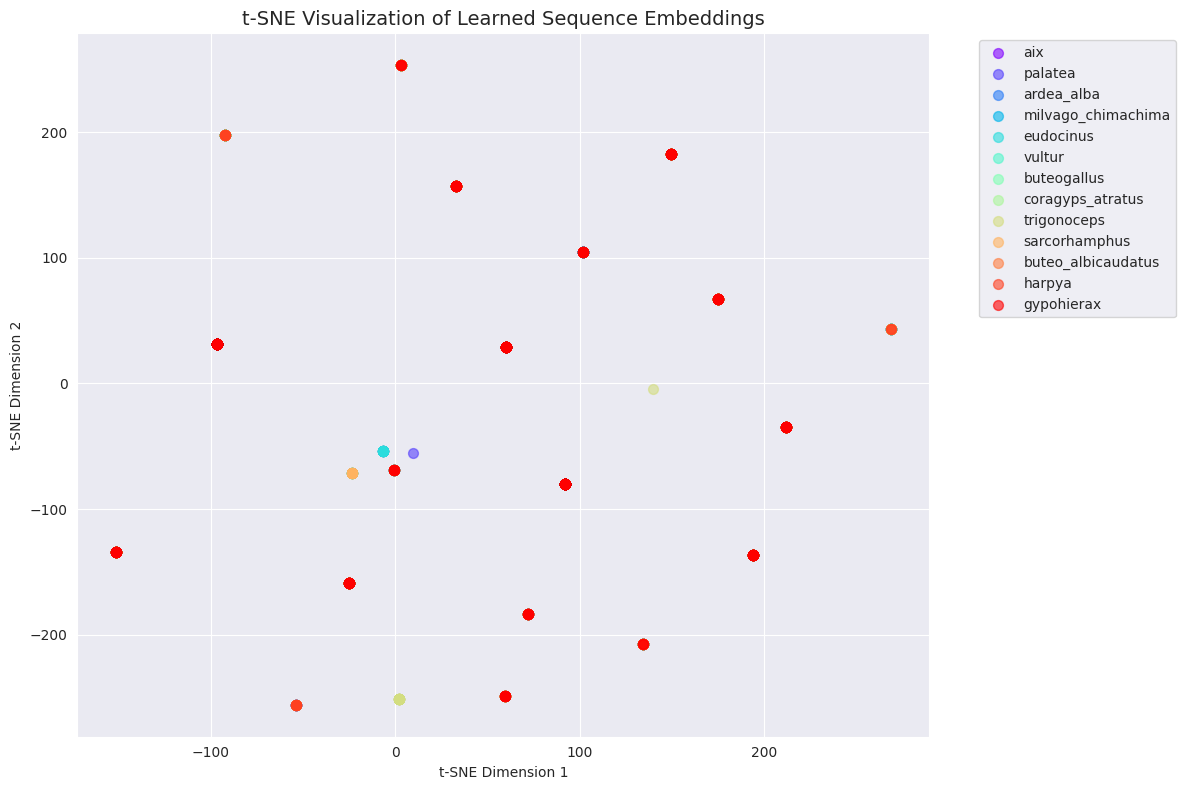


Treinamento concluído!
Embeddings salvos em 'siamese_embeddings.png'
Modelo salvo em 'siamese_model.pth'

Iniciando análise temporal (Cadeias de Markov)...

INICIANDO ANÁLISE TEMPORAL (CADEIAS DE MARKOV)

--- Top 10 Motivos Comportamentais (Trigramas) Globais ---
Empty DataFrame
Columns: []
Index: []

--- Comparação de Regras de Transição ---
Espécies: aix vs palatea
Similaridade das transições (0 a 1): 1.0000
Divergência JS: 0.0000

Gerando visualizações para: aix


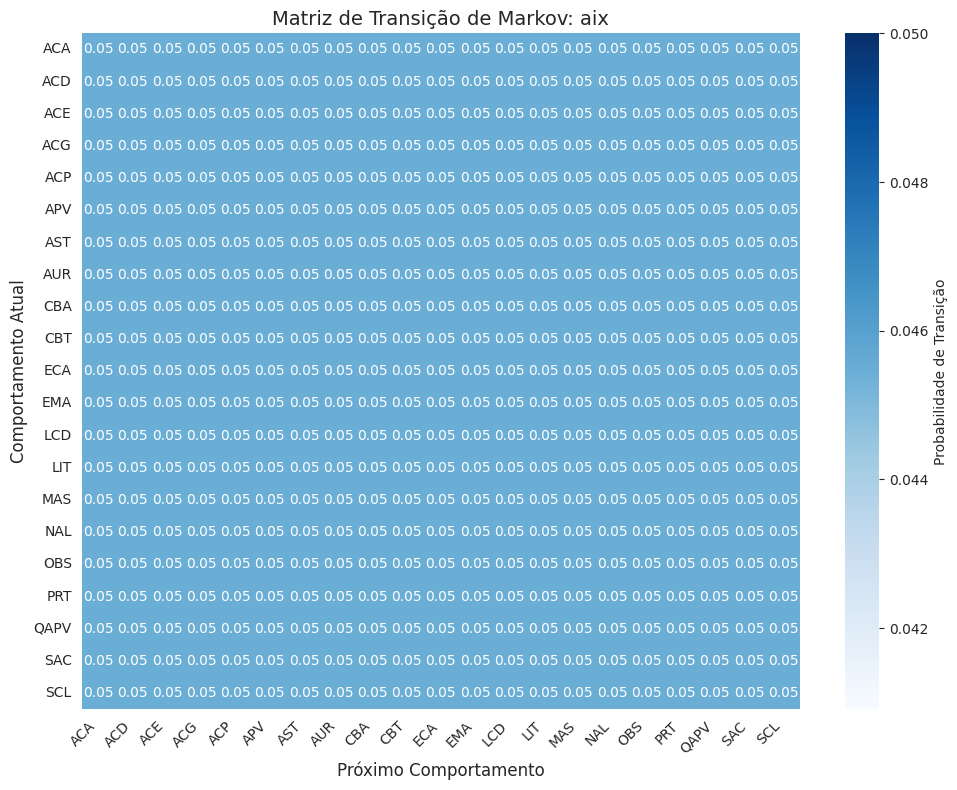

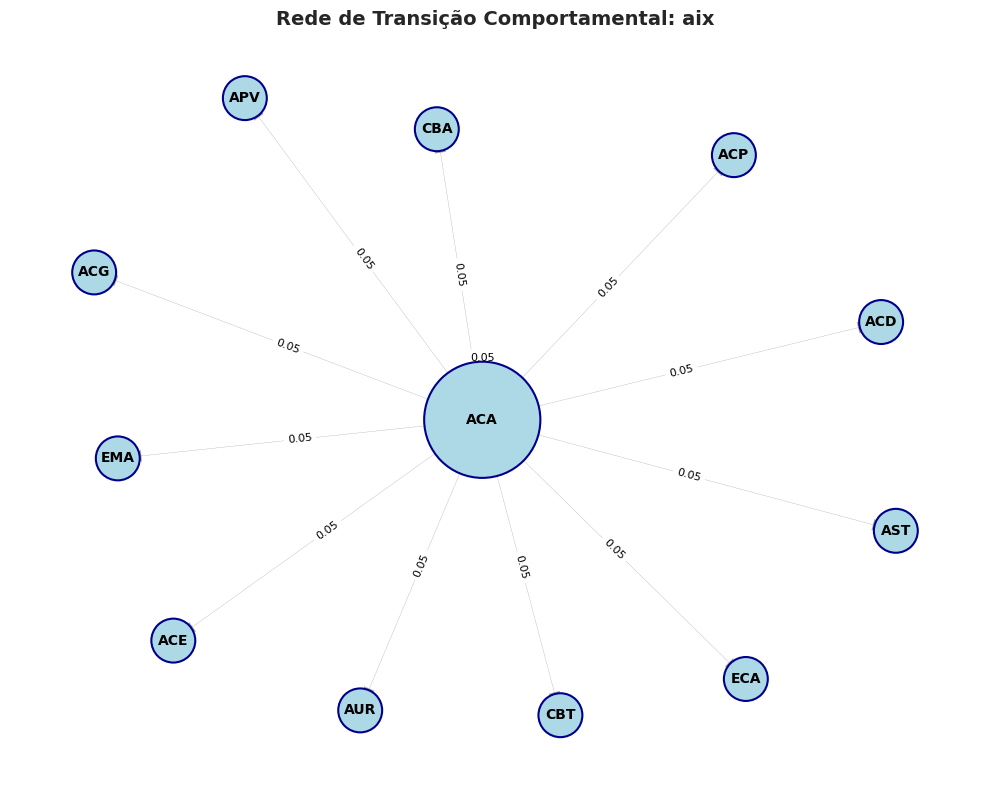

Top 5 motivos para aix:


KeyError: "None of [Index(['motif', 'frequency'], dtype='str')] are in the [columns]"

In [8]:
# notebook code1/redes_siamesas.py
# Configurações
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# ============================================
# 1. PRÉ-PROCESSAMENTO DOS DADOS
# ============================================

class SequenceProcessor:
    """Processa as sequências comportamentais do CSV"""

    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)
        self.vocab = self._build_vocab()
        self.species_names = self.df.columns.tolist()

    def _build_vocab(self):
        """Constrói vocabulário de todos os comportamentos"""
        all_behaviors = set()
        for col in self.df.columns:
            sequences = self.df[col].dropna().astype(str)
            for seq in sequences:
                all_behaviors.update(seq.split())

        vocab = {beh: idx + 1 for idx, beh in enumerate(sorted(all_behaviors))}
        vocab['<PAD>'] = 0  # Padding token
        return vocab

    def encode_sequence(self, sequence_str, max_length=100):
        """Converte string de comportamentos em tensor de índices"""
        behaviors = sequence_str.split()
        indices = [self.vocab.get(b, 0) for b in behaviors]

        # Padding ou truncamento
        if len(indices) < max_length:
            indices = indices + [0] * (max_length - len(indices))
        else:
            indices = indices[:max_length]

        return torch.tensor(indices, dtype=torch.long)

    def get_all_sequences(self, max_length=100):
        """Retorna todas as sequências codificadas"""
        sequences = []
        species_labels = []

        for col in self.df.columns:
            for seq in self.df[col].dropna().astype(str):
                sequences.append(self.encode_sequence(seq, max_length))
                species_labels.append(col)

        return sequences, species_labels


# ============================================
# 2. DATASET PARA PARES DE SEQUÊNCIAS
# ============================================

class SiameseSequenceDataset(Dataset):
    """Dataset que gera pares de sequências para treinamento"""

    def __init__(self, sequences, labels, num_pairs=1000):
        self.sequences = sequences
        self.labels = labels
        self.num_pairs = num_pairs

        # Agrupa por espécie
        self.species_indices = {}
        for idx, label in enumerate(labels):
            if label not in self.species_indices:
                self.species_indices[label] = []
            self.species_indices[label].append(idx)

        self.pairs = self._generate_pairs()

    def _generate_pairs(self):
        """Gera pares positivos (mesma espécie) e negativos (espécies diferentes)"""
        pairs = []
        species_list = list(self.species_indices.keys())

        for _ in range(self.num_pairs):
            if random.random() < 0.5:  # Par positivo (mesma espécie)
                species = random.choice(species_list)
                indices = self.species_indices[species]
                if len(indices) >= 2:
                    idx1, idx2 = random.sample(indices, 2)
                    pairs.append((idx1, idx2, 1))  # Label 1 = similar
            else:  # Par negativo (espécies diferentes)
                species1, species2 = random.sample(species_list, 2)
                idx1 = random.choice(self.species_indices[species1])
                idx2 = random.choice(self.species_indices[species2])
                pairs.append((idx1, idx2, 0))  # Label 0 = dissimilar

        return pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        idx1, idx2, label = self.pairs[idx]
        return self.sequences[idx1], self.sequences[idx2], torch.tensor(label, dtype=torch.float32)

# ============================================
# 3. ARQUITETURA DA REDE SIAMESA
# ============================================

class SequenceEncoder(nn.Module):
    """Encoder de sequências com Embedding + LSTM"""

    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, num_layers=2):
        super(SequenceEncoder, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

    def forward(self, x):
        # x: (batch_size, seq_length)
        embedded = self.embedding(x)  # (batch, seq_len, embedding_dim)

        # LSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)

        # Usa a concatenação dos últimos estados hidden de ambas as direções
        hidden_fwd = hidden[-2]  # Última camada forward
        hidden_bwd = hidden[-1]  # Última camada backward
        encoding = torch.cat([hidden_fwd, hidden_bwd], dim=1)

        return encoding


class SiameseNetwork(nn.Module):
    """Rede Siamesa completa"""

    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128):
        super(SiameseNetwork, self).__init__()

        self.encoder = SequenceEncoder(vocab_size, embedding_dim, hidden_dim)

    def forward(self, seq1, seq2):
        # Codifica ambas as sequências
        encoding1 = self.encoder(seq1)
        encoding2 = self.encoder(seq2)

        return encoding1, encoding2

# ============================================
# 4. FUNÇÃO DE PERDA
# ============================================

class ContrastiveLoss(nn.Module):
    """Contrastive Loss para redes siamesas"""

    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, encoding1, encoding2, label):
        # Distância euclidiana
        distance = torch.nn.functional.pairwise_distance(encoding1, encoding2)

        # Loss: para pares similares (label=1), minimiza distância
        #       para pares dissimilares (label=0), maximiza distância (até margin)
        loss = (label * distance.pow(2) +
                (1 - label) * torch.clamp(self.margin - distance, min=0.0).pow(2))

        return loss.mean()

# ============================================
# 5. TREINAMENTO
# ============================================

def train_model(model, train_loader, criterion, optimizer, num_epochs=20, device='cpu'):
    """Treina a rede siamesa"""

    model = model.to(device)
    model.train()

    for epoch in range(num_epochs):
        total_loss = 0

        for seq1, seq2, labels in train_loader:
            seq1, seq2, labels = seq1.to(device), seq2.to(device), labels.to(device)

            optimizer.zero_grad()

            # Forward pass
            encoding1, encoding2 = model(seq1, seq2)
            loss = criterion(encoding1, encoding2, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

    return model


# ============================================
# 6. VISUALIZAÇÃO DOS EMBEDDINGS
# ============================================

def visualize_embeddings(model, sequences, species_labels, device='cpu'):
    """Visualiza os embeddings aprendidos usando t-SNE"""

    model.eval()
    model = model.to(device)

    # Extrai embeddings de todas as sequências
    embeddings = []
    with torch.no_grad():
        for seq in sequences:
            seq = seq.unsqueeze(0).to(device)
            encoding = model.encoder(seq)
            embeddings.append(encoding.cpu().numpy())

    embeddings = np.vstack(embeddings)

    # t-SNE para redução de dimensionalidade
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1))
    embeddings_2d = tsne.fit_transform(embeddings)

    # Plot
    plt.figure(figsize=(12, 8))
    unique_species = list(set(species_labels))
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_species)))

    for species, color in zip(unique_species, colors):
        indices = [i for i, label in enumerate(species_labels) if label == species]
        plt.scatter(
            embeddings_2d[indices, 0],
            embeddings_2d[indices, 1],
            c=[color],
            label=species,
            alpha=0.6,
            s=50
        )

    plt.title('t-SNE Visualization of Learned Sequence Embeddings', fontsize=14)
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('siamese_embeddings.png', dpi=300, bbox_inches='tight')
    plt.show()

    return embeddings_2d


# ============================================
# 7. EXEMPLO DE USO
# ============================================

def main():
    # Configurações
    CSV_PATH = 'sequencias/sequencias_todas.csv'  # Substitua pelo caminho do seu CSV
    MAX_SEQ_LENGTH = 100
    EMBEDDING_DIM = 64
    HIDDEN_DIM = 128
    NUM_PAIRS = 2000
    BATCH_SIZE = 32
    NUM_EPOCHS = 20
    LEARNING_RATE = 0.001

    # 1. Processa os dados
    print("Processando dados...")
    processor = SequenceProcessor(CSV_PATH)
    sequences, species_labels = processor.get_all_sequences(MAX_SEQ_LENGTH)
    vocab_size = len(processor.vocab)

    print(f"Vocabulário: {vocab_size} comportamentos únicos")
    print(f"Total de sequências: {len(sequences)}")
    print(f"Espécies: {len(set(species_labels))}")

    # 2. Cria dataset e dataloader
    dataset = SiameseSequenceDataset(sequences, species_labels, NUM_PAIRS)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    # 3. Inicializa modelo
    model = SiameseNetwork(vocab_size, EMBEDDING_DIM, HIDDEN_DIM)
    criterion = ContrastiveLoss(margin=2.0)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 4. Treina
    print("\nIniciando treinamento...")
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = train_model(model, dataloader, criterion, optimizer, NUM_EPOCHS, device)

    # 5. Visualiza embeddings
    print("\nGerando visualização dos embeddings...")
    embeddings_2d = visualize_embeddings(model, sequences, species_labels, device)

    print("\nTreinamento concluído!")
    print("Embeddings salvos em 'siamese_embeddings.png'")

    # Salva o modelo
    torch.save(model.state_dict(), 'siamese_model.pth')
    print("Modelo salvo em 'siamese_model.pth'")


# ============================================================
# 5. ANÁLISE TEMPORAL (CORRIGIDA)
# ============================================================
    print("\nIniciando análise temporal (Cadeias de Markov)...")

    # Converte tensors PyTorch para listas de inteiros (compatibilidade)
    sequences_lists = [seq.tolist() if hasattr(seq, 'tolist') else seq for seq in sequences]

    run_temporal_analysis(processor, sequences_lists, species_labels)

    print("\n✅ Pipeline completo finalizado!")
    print("Arquivos gerados: embeddings, clusters, heatmaps, redes de transição, etc.")



if __name__ == "__main__":
    main()


Carregando dados e modelo...
Extraindo embeddings...
Total de sequências: 11096
Total de espécies: 13

=== ANÁLISE DE CLUSTERS ===
K=2: Silhouette Score = 0.3937
K=3: Silhouette Score = 0.4972
K=4: Silhouette Score = 0.5641
K=5: Silhouette Score = 0.6282
K=6: Silhouette Score = 0.6852
K=7: Silhouette Score = 0.7393
K=8: Silhouette Score = 0.7703
K=9: Silhouette Score = 0.8064
K=10: Silhouette Score = 0.8476


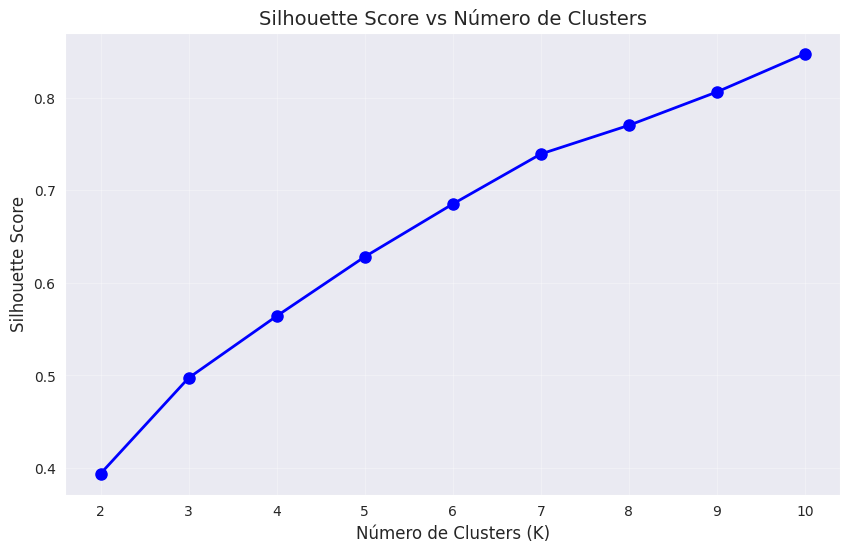


Número ótimo de clusters: 10


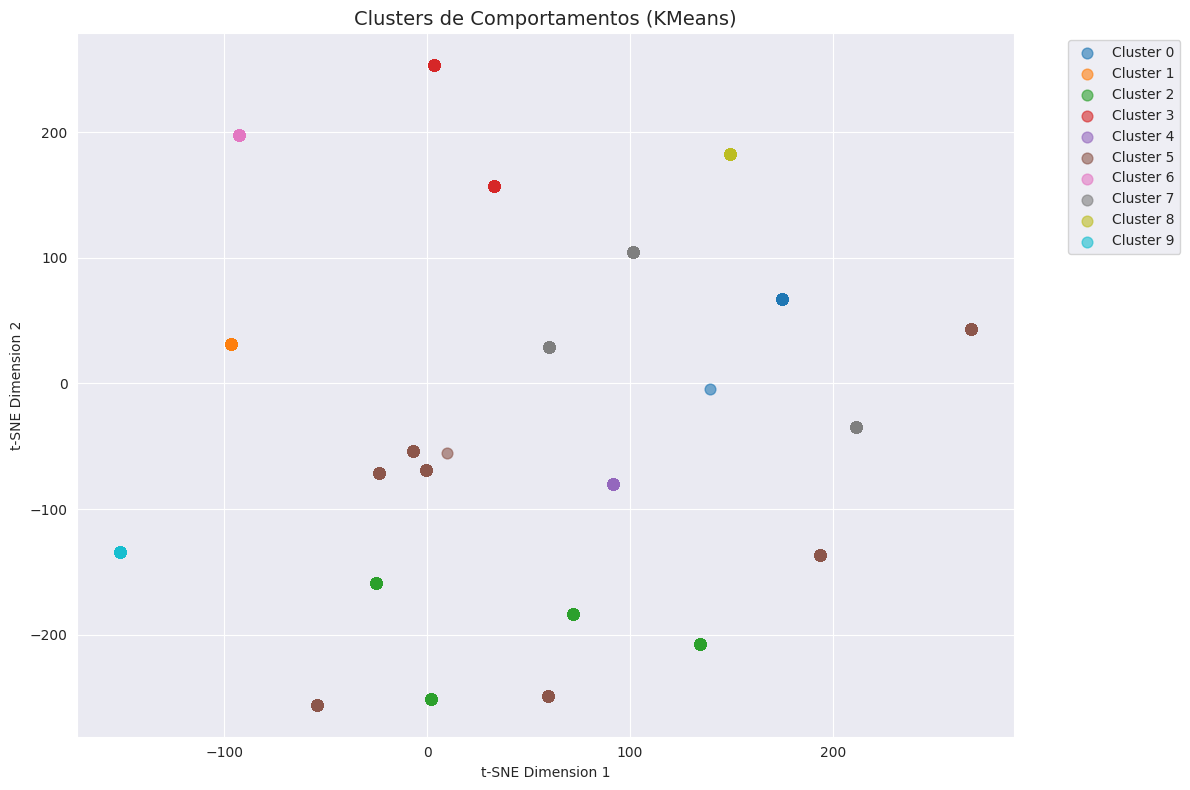


=== Composição dos Clusters ===

Cluster 0:
  - aix: 169 sequências
  - eudocinus: 120 sequências
  - palatea: 107 sequências
  - ardea_alba: 87 sequências
  - vultur: 60 sequências
  - coragyps_atratus: 43 sequências
  - sarcorhamphus: 32 sequências
  - trigonoceps: 28 sequências
  - harpya: 25 sequências
  - buteo_albicaudatus: 17 sequências
  - buteogallus: 17 sequências
  - milvago_chimachima: 16 sequências
  - gypohierax: 8 sequências

Cluster 1:
  - aix: 607 sequências
  - palatea: 577 sequências
  - eudocinus: 468 sequências
  - sarcorhamphus: 337 sequências
  - ardea_alba: 259 sequências
  - vultur: 250 sequências
  - coragyps_atratus: 241 sequências
  - gypohierax: 235 sequências
  - harpya: 224 sequências
  - buteogallus: 205 sequências
  - trigonoceps: 202 sequências
  - buteo_albicaudatus: 191 sequências
  - milvago_chimachima: 166 sequências

Cluster 2:
  - eudocinus: 212 sequências
  - palatea: 196 sequências
  - aix: 170 sequências
  - trigonoceps: 95 sequências
  - sar

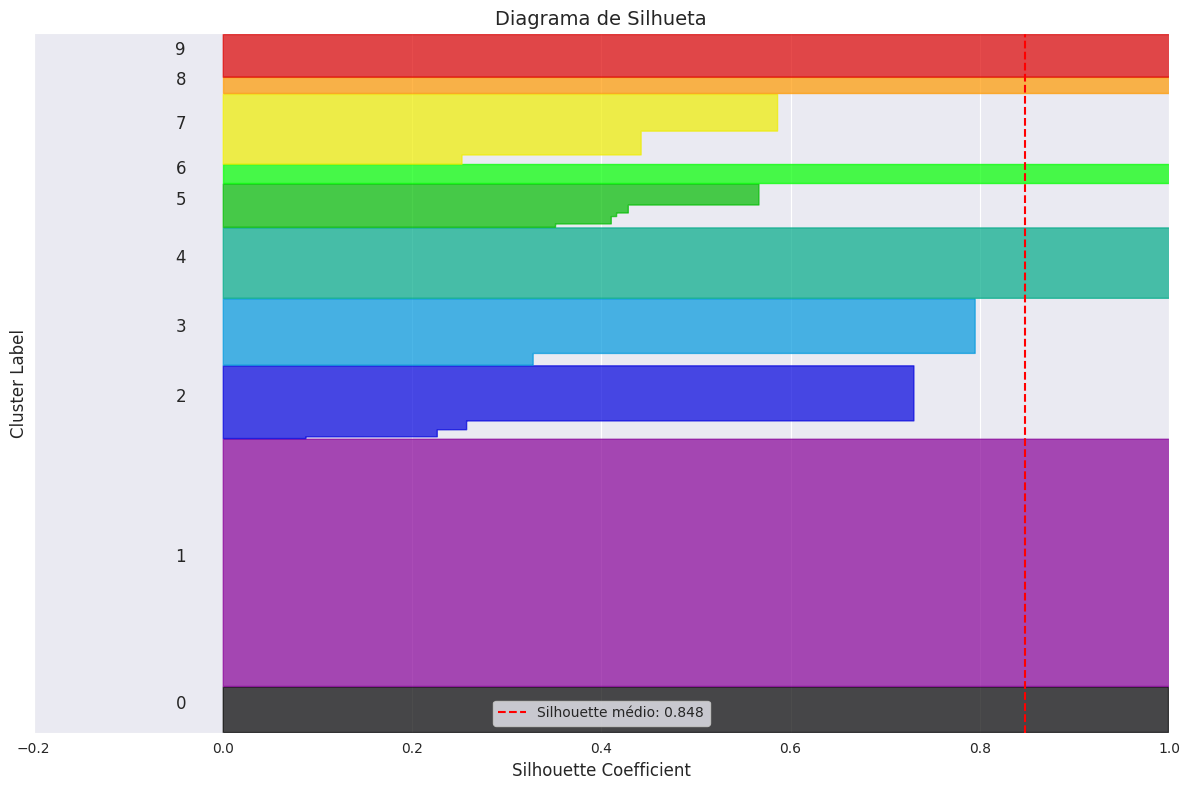


=== COMPARAÇÃO ENTRE ESPÉCIES ===


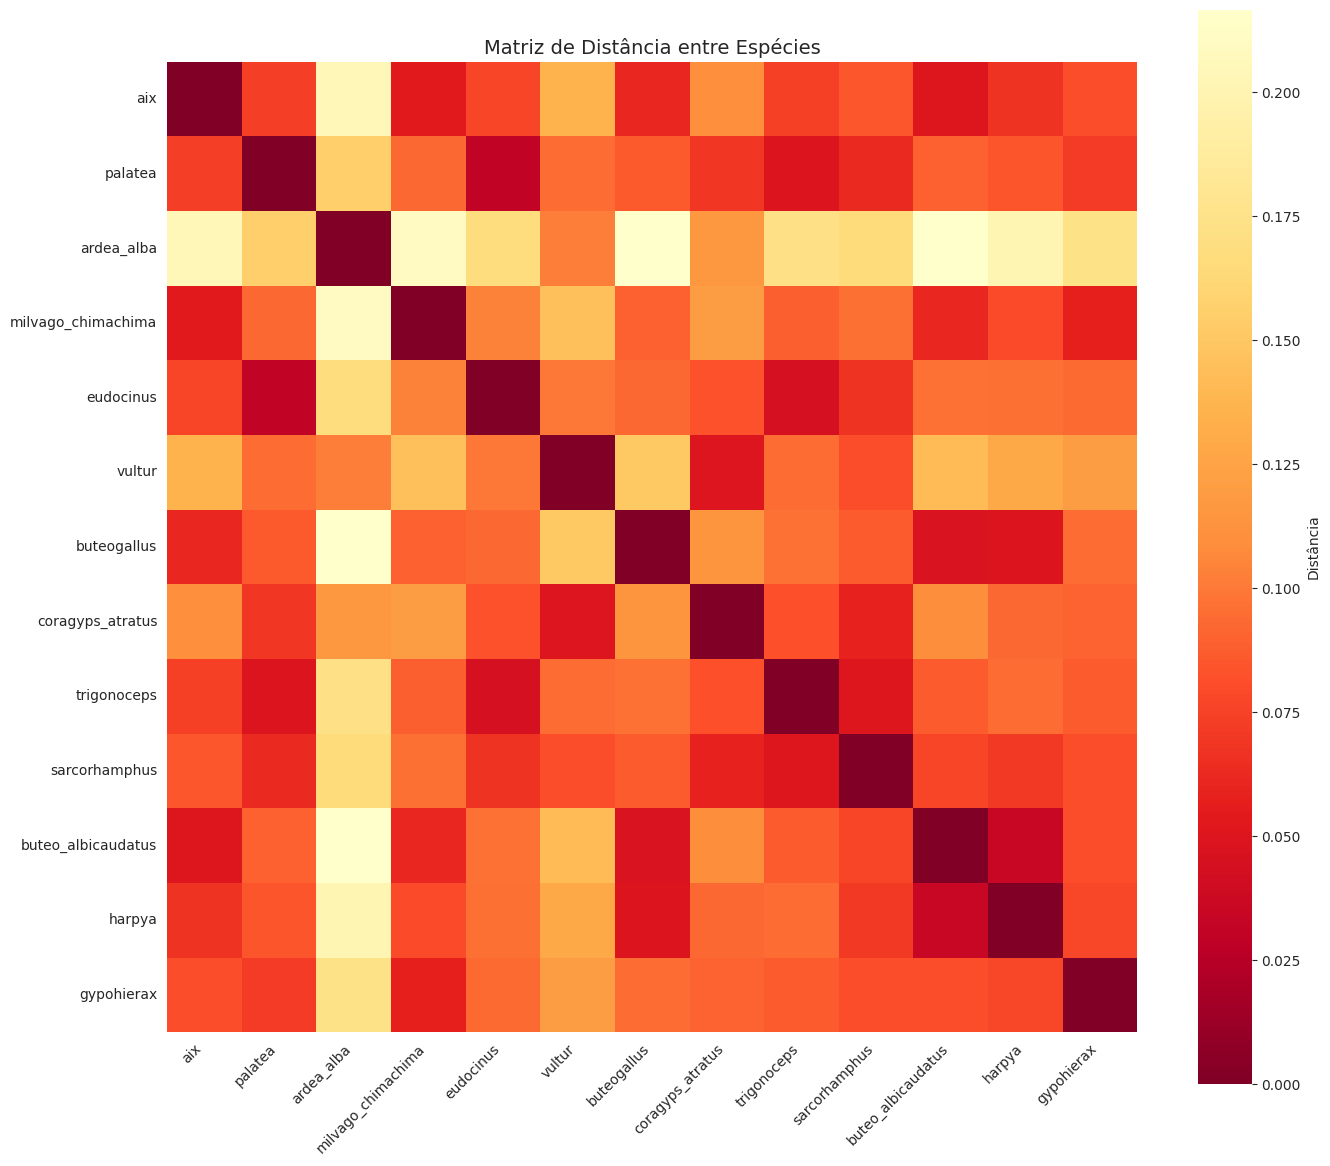

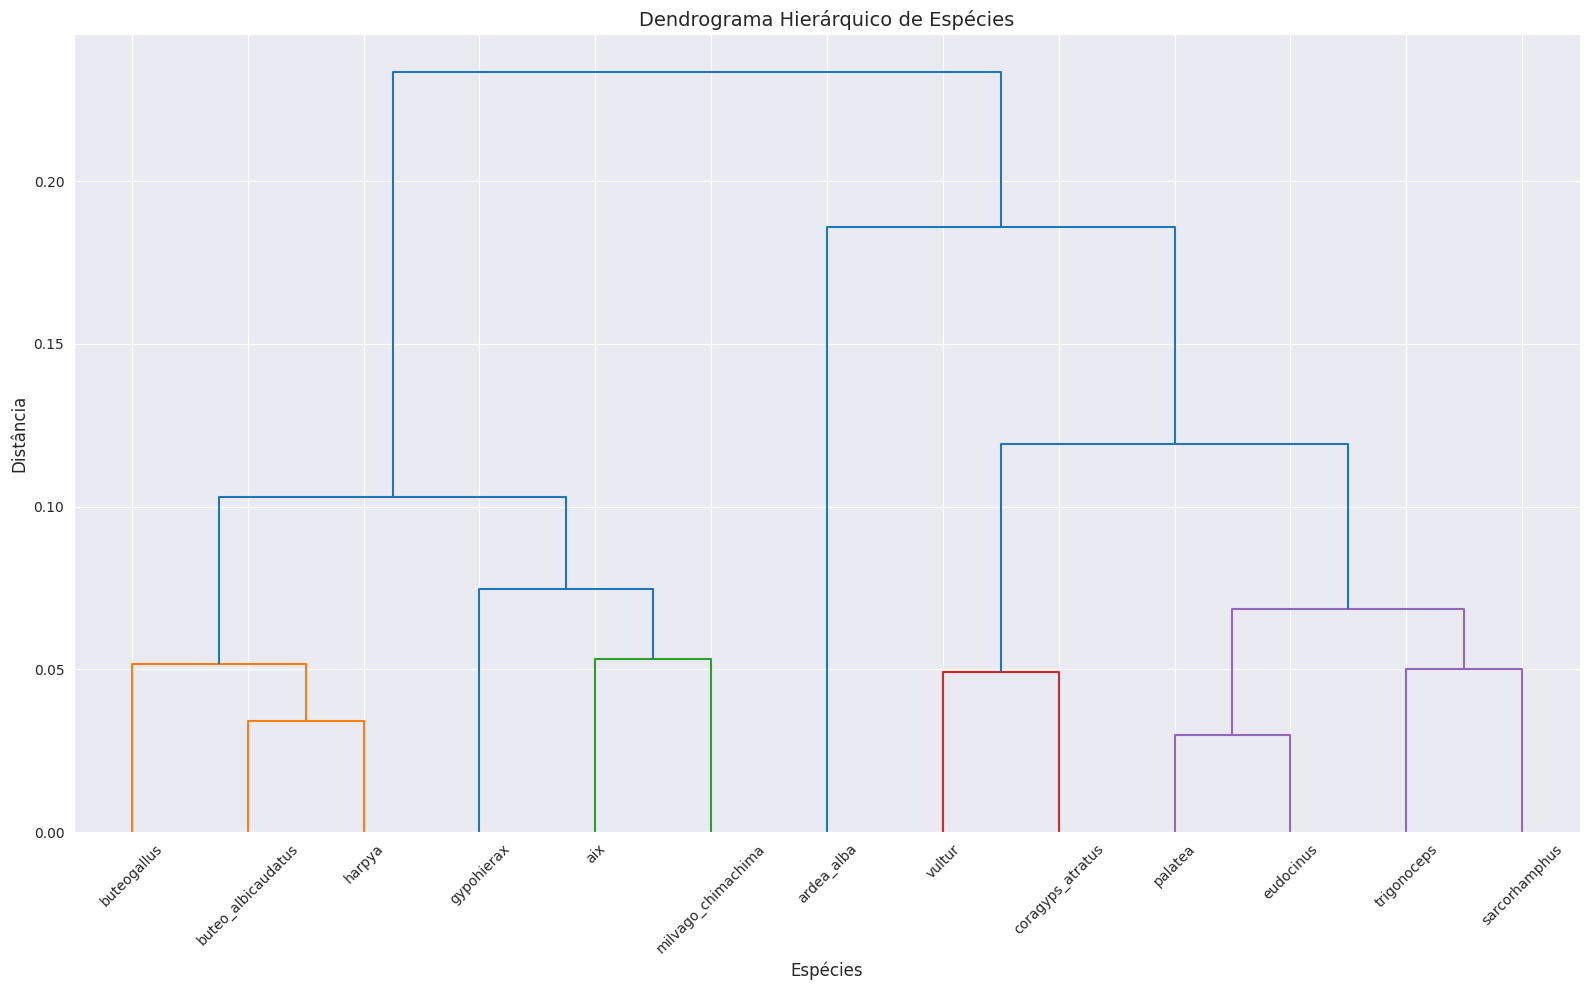


=== Top 10 Pares Mais Similares ===
palatea (N/A) ↔ eudocinus (N/A): 0.0299
buteo_albicaudatus (N/A) ↔ harpya (N/A): 0.0343
eudocinus (N/A) ↔ trigonoceps (N/A): 0.0447
buteogallus (N/A) ↔ buteo_albicaudatus (N/A): 0.0473
buteogallus (N/A) ↔ harpya (N/A): 0.0486
palatea (N/A) ↔ trigonoceps (N/A): 0.0490
vultur (N/A) ↔ coragyps_atratus (N/A): 0.0493
trigonoceps (N/A) ↔ sarcorhamphus (N/A): 0.0502
aix (N/A) ↔ buteo_albicaudatus (N/A): 0.0504
aix (N/A) ↔ milvago_chimachima (N/A): 0.0532

=== Top 10 Pares Mais Dissimilares ===
palatea (N/A) ↔ ardea_alba (N/A): 0.1555
ardea_alba (N/A) ↔ sarcorhamphus (N/A): 0.1666
ardea_alba (N/A) ↔ eudocinus (N/A): 0.1675
ardea_alba (N/A) ↔ trigonoceps (N/A): 0.1727
ardea_alba (N/A) ↔ gypohierax (N/A): 0.1736
ardea_alba (N/A) ↔ harpya (N/A): 0.2012
aix (N/A) ↔ ardea_alba (N/A): 0.2036
ardea_alba (N/A) ↔ milvago_chimachima (N/A): 0.2094
ardea_alba (N/A) ↔ buteogallus (N/A): 0.2161
ardea_alba (N/A) ↔ buteo_albicaudatus (N/A): 0.2165

=== ANÁLISE CONCLUÍDA ==

NameError: name 'processor' is not defined

In [6]:
# notebook code2/cluster_analysis.py

# ============================================
# 1. EXTRAÇÃO DE EMBEDDINGS
# ============================================

class EmbeddingExtractor:
    """Extrai embeddings das sequências usando o modelo treinado"""

    def __init__(self, model, processor, device='cpu'):
        self.model = model.to(device)
        self.processor = processor
        self.device = device
        self.model.eval()

    def extract_all_embeddings(self):
        """Extrai embeddings de todas as sequências"""
        embeddings = []
        species_labels = []

        with torch.no_grad():
            for col in self.processor.df.columns:
                for seq in self.processor.df[col].dropna().astype(str):
                    encoded = self.processor.encode_sequence(seq)
                    encoded = encoded.unsqueeze(0).to(self.device)
                    embedding = self.model.encoder(encoded)
                    embeddings.append(embedding.cpu().numpy().flatten())
                    species_labels.append(col)

        return np.array(embeddings), species_labels

    def extract_species_embeddings(self):
        """Extrai embeddings médios por espécie"""
        embeddings, labels = self.extract_all_embeddings()

        species_embeddings = {}
        for species in set(labels):
            indices = [i for i, label in enumerate(labels) if label == species]
            species_mean = np.mean(embeddings[indices], axis=0)
            species_embeddings[species] = species_mean

        return species_embeddings


# ============================================
# 2. ANÁLISE DE CLUSTERS
# ============================================

class ClusterAnalyzer:
    """Analisa clusters no espaço de embeddings"""

    def __init__(self, embeddings, labels):
        self.embeddings = embeddings
        self.labels = labels
        self.unique_labels = list(set(labels))

    def find_optimal_clusters(self, max_k=10):
        """Encontra número ótimo de clusters usando silhouette score"""
        silhouette_scores = []
        K_range = range(2, min(max_k + 1, len(self.unique_labels)))

        for k in K_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            cluster_labels = kmeans.fit_predict(self.embeddings)
            score = silhouette_score(self.embeddings, cluster_labels)
            silhouette_scores.append(score)
            print(f"K={k}: Silhouette Score = {score:.4f}")

        # Plot
        plt.figure(figsize=(10, 6))
        plt.plot(K_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
        plt.xlabel('Número de Clusters (K)', fontsize=12)
        plt.ylabel('Silhouette Score', fontsize=12)
        plt.title('Silhouette Score vs Número de Clusters', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.savefig('silhouette_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

        optimal_k = K_range[np.argmax(silhouette_scores)]
        print(f"\nNúmero ótimo de clusters: {optimal_k}")
        return optimal_k

    def perform_kmeans_clustering(self, n_clusters):
        """Aplica K-Means clustering"""
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(self.embeddings)

        return cluster_labels, kmeans

    def perform_dbscan_clustering(self, eps=0.5, min_samples=5):
        """Aplica DBSCAN clustering"""
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        cluster_labels = dbscan.fit_predict(self.embeddings)

        return cluster_labels, dbscan

    def visualize_clusters(self, cluster_labels, method='KMeans'):
        """Visualiza clusters usando t-SNE"""
        from sklearn.manifold import TSNE

        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(self.embeddings)-1))
        embeddings_2d = tsne.fit_transform(self.embeddings)

        plt.figure(figsize=(12, 8))

        # Cores para cada cluster
        unique_clusters = set(cluster_labels)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))

        for cluster, color in zip(unique_clusters, colors):
            if cluster == -1:  # Ruído no DBSCAN
                continue
            indices = [i for i, label in enumerate(cluster_labels) if label == cluster]
            plt.scatter(
                embeddings_2d[indices, 0],
                embeddings_2d[indices, 1],
                c=[color],
                label=f'Cluster {cluster}',
                alpha=0.6,
                s=60
            )

        # Marca ruídos (se houver)
        noise_indices = [i for i, label in enumerate(cluster_labels) if label == -1]
        if noise_indices:
            plt.scatter(
                embeddings_2d[noise_indices, 0],
                embeddings_2d[noise_indices, 1],
                c='black',
                marker='x',
                s=50,
                label='Ruído'
            )

        plt.title(f'Clusters de Comportamentos ({method})', fontsize=14)
        plt.xlabel('t-SNE Dimension 1')
        plt.ylabel('t-SNE Dimension 2')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(f'clusters_{method.lower()}.png', dpi=300, bbox_inches='tight')
        plt.show()

        return embeddings_2d

    def analyze_cluster_composition(self, cluster_labels):
        """Analisa quais espécies estão em cada cluster"""
        cluster_composition = {}

        for cluster in set(cluster_labels):
            if cluster == -1:
                continue
            indices = [i for i, label in enumerate(cluster_labels) if label == cluster]
            species_in_cluster = [self.labels[i] for i in indices]
            cluster_composition[cluster] = Counter(species_in_cluster)

        print("\n=== Composição dos Clusters ===")
        for cluster, composition in cluster_composition.items():
            print(f"\nCluster {cluster}:")
            for species, count in composition.most_common():
                print(f"  - {species}: {count} sequências")

        return cluster_composition

    def plot_silhouette_diagram(self, cluster_labels, n_clusters):
        """Plota diagrama de silhueta para validar clusters"""
        fig, ax1 = plt.subplots(1, 1, figsize=(12, 8))

        ax1.set_xlim([-0.2, 1])
        ax1.set_ylim([0, len(self.embeddings) + (n_clusters + 1) * 10])

        silhouette_avg = silhouette_score(self.embeddings, cluster_labels)
        print(f"Silhouette Score médio: {silhouette_avg:.4f}")

        sample_silhouette_values = silhouette_samples(self.embeddings, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = plt.cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(np.arange(y_lower, y_upper),
                              0, ith_cluster_silhouette_values,
                              facecolor=color, edgecolor=color, alpha=0.7)

            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=12)
            y_lower = y_upper + 10

        ax1.axvline(x=silhouette_avg, color="red", linestyle="--",
                    label=f'Silhouette médio: {silhouette_avg:.3f}')
        ax1.set_yticks([])
        ax1.set_xticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
        ax1.set_xlabel('Silhouette Coefficient', fontsize=12)
        ax1.set_ylabel('Cluster Label', fontsize=12)
        ax1.set_title('Diagrama de Silhueta', fontsize=14)
        ax1.legend()
        plt.tight_layout()
        plt.savefig('silhouette_diagram.png', dpi=300, bbox_inches='tight')
        plt.show()


# ============================================
# 3. COMPARAÇÃO ENTRE ESPÉCIES/FAMÍLIAS
# ============================================

class SpeciesComparator:
    """Compara similaridade entre espécies"""

    def __init__(self, species_embeddings, family_mapping=None):
        """
        Args:
            species_embeddings: dict {species: embedding_vector}
            family_mapping: dict {species: family} (opcional)
        """
        self.species_embeddings = species_embeddings
        self.species_names = list(species_embeddings.keys())
        self.family_mapping = family_mapping

        # Matriz de embeddings
        self.embedding_matrix = np.array([species_embeddings[s] for s in self.species_names])

    def compute_distance_matrix(self, metric='euclidean'):
        """Calcula matriz de distância entre espécies"""
        if metric == 'euclidean':
            distances = euclidean_distances(self.embedding_matrix)
        elif metric == 'cosine':
            distances = 1 - cosine_similarity(self.embedding_matrix)

        return distances

    def plot_distance_heatmap(self, distances):
        """Plota heatmap de distâncias entre espécies"""
        plt.figure(figsize=(14, 12))
        sns.heatmap(
            distances,
            xticklabels=self.species_names,
            yticklabels=self.species_names,
            cmap='YlOrRd_r',
            annot=False,
            fmt='.2f',
            square=True,
            cbar_kws={'label': 'Distância'}
        )
        plt.title('Matriz de Distância entre Espécies', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig('species_distance_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()

    def plot_dendrogram(self, distances):
        """Plota dendrograma hierárquico"""
        condensed_distances = squareform(distances)
        linkage_matrix = linkage(condensed_distances, method='ward')

        plt.figure(figsize=(16, 10))
        dendrogram(
            linkage_matrix,
            labels=self.species_names,
            leaf_rotation=45,
            leaf_font_size=10,
            color_threshold=linkage_matrix[-5, 2] if len(linkage_matrix) > 5 else None
        )
        plt.title('Dendrograma Hierárquico de Espécies', fontsize=14)
        plt.xlabel('Espécies', fontsize=12)
        plt.ylabel('Distância', fontsize=12)
        plt.tight_layout()
        plt.savefig('species_dendrogram.png', dpi=300, bbox_inches='tight')
        plt.show()

    def compare_within_vs_between_families(self):
        """Compara distâncias dentro vs entre famílias (se houver metadados)"""
        if self.family_mapping is None:
            print("⚠️  family_mapping não fornecido. Pulando análise entre famílias.")
            return None

        distances = self.compute_distance_matrix()

        within_distances = []
        between_distances = []

        for i, sp1 in enumerate(self.species_names):
            for j, sp2 in enumerate(self.species_names):
                if i >= j:
                    continue

                fam1 = self.family_mapping.get(sp1)
                fam2 = self.family_mapping.get(sp2)

                if fam1 is None or fam2 is None:
                    continue

                if fam1 == fam2:
                    within_distances.append(distances[i, j])
                else:
                    between_distances.append(distances[i, j])

        if not within_distances or not between_distances:
            print("⚠️  Dados insuficientes para comparação entre famílias.")
            return None

        # Estatísticas
        print("\n=== Comparação Dentro vs Entre Famílias ===")
        print(f"Dentro da família (n={len(within_distances)}):")
        print(f"  Média: {np.mean(within_distances):.4f}")
        print(f"  Mediana: {np.median(within_distances):.4f}")
        print(f"  Desvio padrão: {np.std(within_distances):.4f}")

        print(f"\nEntre famílias (n={len(between_distances)}):")
        print(f"  Média: {np.mean(between_distances):.4f}")
        print(f"  Mediana: {np.median(between_distances):.4f}")
        print(f"  Desvio padrão: {np.std(between_distances):.4f}")

        # Teste estatístico
        from scipy.stats import mannwhitneyu
        stat, p_value = mannwhitneyu(within_distances, between_distances, alternative='less')
        print(f"\nTeste de Mann-Whitney: U={stat:.2f}, p={p_value:.4f}")
        if p_value < 0.05:
            print("✓ Diferença estatisticamente significativa (p < 0.05)")
            print("  Espécies da mesma família são mais similares que espécies de famílias diferentes")
        else:
            print("✗ Diferença não estatisticamente significativa")

        # Boxplot
        plt.figure(figsize=(10, 6))
        plt.boxplot([within_distances, between_distances],
                    labels=['Dentro da Família', 'Entre Famílias'])
        plt.ylabel('Distância Euclidiana', fontsize=12)
        plt.title('Comparação de Distâncias: Dentro vs Entre Famílias', fontsize=14)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.savefig('within_vs_between_families.png', dpi=300, bbox_inches='tight')
        plt.show()

        return {
            'within_distances': within_distances,
            'between_distances': between_distances,
            'p_value': p_value
        }

    def find_most_similar_species(self, n=5):
        """Encontra os pares mais similares"""
        distances = self.compute_distance_matrix()

        pairs = []
        for i in range(len(self.species_names)):
            for j in range(i + 1, len(self.species_names)):
                pairs.append({
                    'species1': self.species_names[i],
                    'species2': self.species_names[j],
                    'distance': distances[i, j]
                })

        pairs_df = pd.DataFrame(pairs)
        pairs_df = pairs_df.sort_values('distance')

        print(f"\n=== Top {n} Pares Mais Similares ===")
        for idx, row in pairs_df.head(n).iterrows():
            fam1 = self.family_mapping.get(row['species1'], 'N/A') if self.family_mapping else 'N/A'
            fam2 = self.family_mapping.get(row['species2'], 'N/A') if self.family_mapping else 'N/A'
            print(f"{row['species1']} ({fam1}) ↔ {row['species2']} ({fam2}): {row['distance']:.4f}")

        print(f"\n=== Top {n} Pares Mais Dissimilares ===")
        for idx, row in pairs_df.tail(n).iterrows():
            fam1 = self.family_mapping.get(row['species1'], 'N/A') if self.family_mapping else 'N/A'
            fam2 = self.family_mapping.get(row['species2'], 'N/A') if self.family_mapping else 'N/A'
            print(f"{row['species1']} ({fam1}) ↔ {row['species2']} ({fam2}): {row['distance']:.4f}")

        return pairs_df


# ============================================
# 4. EXEMPLO DE USO COMPLETO
# ============================================

def main():
    # Configurações
    CSV_PATH = 'sequencias/sequencias_todas.csv'
    MODEL_PATH = 'siamese_model.pth'
    MAX_SEQ_LENGTH = 100
    EMBEDDING_DIM = 64
    HIDDEN_DIM = 128

    # 1. Carrega dados e modelo
    print("Carregando dados e modelo...")

    # Importa classes do script anterior
    from siamese_network import SequenceProcessor, SiameseNetwork

    processor = SequenceProcessor(CSV_PATH)
    vocab_size = len(processor.vocab)

    model = SiameseNetwork(vocab_size, EMBEDDING_DIM, HIDDEN_DIM)
    model.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))

    # 2. Extrai embeddings
    print("Extraindo embeddings...")
    extractor = EmbeddingExtractor(model, processor)
    embeddings, species_labels = extractor.extract_all_embeddings()
    species_embeddings = extractor.extract_species_embeddings()

    print(f"Total de sequências: {len(embeddings)}")
    print(f"Total de espécies: {len(species_embeddings)}")

    # 3. Análise de clusters
    print("\n=== ANÁLISE DE CLUSTERS ===")
    cluster_analyzer = ClusterAnalyzer(embeddings, species_labels)

    # Encontra número ótimo de clusters
    optimal_k = cluster_analyzer.find_optimal_clusters(max_k=10)

    # Aplica K-Means
    cluster_labels, kmeans = cluster_analyzer.perform_kmeans_clustering(optimal_k)
    cluster_analyzer.visualize_clusters(cluster_labels, method='KMeans')
    cluster_analyzer.analyze_cluster_composition(cluster_labels)
    cluster_analyzer.plot_silhouette_diagram(cluster_labels, optimal_k)

    # 4. Comparação entre espécies
    print("\n=== COMPARAÇÃO ENTRE ESPÉCIES ===")

    # Exemplo de family_mapping (você deve adaptar para seus dados)
    # family_mapping = {
    #     'species1': 'Family_A',
    #     'species2': 'Family_A',
    #     'species3': 'Family_B',
    #     ...
    # }
    family_mapping = None  # Substitua por seus dados

    comparator = SpeciesComparator(species_embeddings, family_mapping)

    # Matriz de distância e dendrograma
    distances = comparator.compute_distance_matrix()
    comparator.plot_distance_heatmap(distances)
    comparator.plot_dendrogram(distances)

    # Pares mais similares/dissimilares
    comparator.find_most_similar_species(n=10)

    # Comparação dentro vs entre famílias (se houver metadados)
    if family_mapping:
        comparator.compare_within_vs_between_families()

    print("\n=== ANÁLISE CONCLUÍDA ===")
    print("Arquivos gerados:")
    print("  - silhouette_analysis.png")
    print("  - clusters_kmeans.png")
    print("  - silhouette_diagram.png")
    print("  - species_distance_heatmap.png")
    print("  - species_dendrogram.png")
    print("  - within_vs_between_families.png (se family_mapping fornecido)")


if __name__ == "__main__":
    main()
    print("Iniciando análise temporal...")
    run_temporal_analysis(processor, sequences, species_labels)

In [5]:
# notebook code3/temporal_analysis.py

# ============================================
# 1. ANALISADOR TEMPORAL (CADEIAS DE MARKOV)
# ============================================

class TemporalAnalyzer:
    """Analisa padrões de transição e dinâmica temporal das sequências"""

    def __init__(self, sequences, labels, vocab):
        """
        Args:
            sequences: Lista de listas de índices inteiros (sequências codificadas)
            labels: Lista de strings com os nomes das espécies correspondentes
            vocab: Dicionário {comportamento: índice} do SequenceProcessor
        """
        self.sequences = sequences
        self.labels = labels
        self.vocab = vocab
        self.reverse_vocab = {v: k for k, v in vocab.items()}
        self.vocab_size = len(vocab)

        # Dicionário para armazenar matrizes de transição por espécie
        self.transition_matrices = {}
        self._build_all_matrices()

    def _build_all_matrices(self):
        """Constrói a matriz de transição de probabilidade para cada espécie"""
        species_sequences = {}

        # Agrupa sequências por espécie
        for seq, label in zip(self.sequences, self.labels):
            if label not in species_sequences:
                species_sequences[label] = []
            species_sequences[label].append(seq)

        # Calcula matriz para cada espécie
        for species, seqs in species_sequences.items():
            self.transition_matrices[species] = self._compute_markov_matrix(seqs)

    def _compute_markov_matrix(self, sequences, smoothing=1e-4):
        """
        Calcula a matriz de transição de Markov (P(t|t-1))
        Aplica suavização de Laplace para evitar probabilidades zero.
        """
        # Matriz de contagem N x N
        counts = np.zeros((self.vocab_size, self.vocab_size))

        for seq in sequences:
            for i in range(len(seq) - 1):
                current_state = seq[i]
                next_state = seq[i+1]

                # Ignora tokens de padding (índice 0)
                if current_state == 0 or next_state == 0:
                    continue

                counts[current_state, next_state] += 1

        # Suavização de Laplace (evita divisões por zero e probs nulas)
        counts += smoothing

        # Normaliza pelas linhas para obter probabilidades
        row_sums = counts.sum(axis=1, keepdims=True)
        transition_probs = counts / row_sums

        return transition_probs

    def compare_species_transitions(self, species1, species2):
        """
        Compara a similaridade das regras de transição entre duas espécies
        usando a Divergência de Jensen-Shannon (simétrica e limitada entre 0 e 1).
        """
        mat1 = self.transition_matrices[species1]
        mat2 = self.transition_matrices[species2]

        # Calcula JS divergence para cada linha (estado) e tira a média
        js_distances = []
        for i in range(self.vocab_size):
            # Ignora estados que são apenas padding ou não ocorrem
            if self.reverse_vocab[i] == '<PAD>':
                continue

            js_dist = jensenshannon(mat1[i], mat2[i], base=2)
            js_distances.append(js_dist)

        mean_js_distance = np.mean(js_distances)
        similarity_score = 1.0 - mean_js_distance  # Converte distância em similaridade

        return similarity_score, mean_js_distance

    def extract_top_motifs(self, n=3, top_k=10, species=None):
        """
        Extrai os N-grams (motivos) mais frequentes nas sequências.
        n: tamanho do motivo (2 = bigrama, 3 = trigrama)
        """
        motif_counter = Counter()

        target_seqs = self.sequences
        if species:
            target_seqs = [seq for seq, label in zip(self.sequences, self.labels) if label == species]

        for seq in target_seqs:
            # Remove paddings para análise limpa
            clean_seq = [state for state in seq if state != 0]

            for i in range(len(clean_seq) - n + 1):
                motif = tuple(clean_seq[i:i+n])
                motif_counter[motif] += 1

        # Converte índices de volta para nomes de comportamentos
        top_motifs = []
        for motif, count in motif_counter.most_common(top_k):
            behavior_names = [self.reverse_vocab[state] for state in motif]
            top_motifs.append({
                'motif': ' -> '.join(behavior_names),
                'count': count,
                'frequency': count / sum(motif_counter.values())
            })

        return pd.DataFrame(top_motifs)

    def plot_transition_network(self, species, top_k_transitions=15, figsize=(10, 8)):
        """
        Plota um grafo direcionado das transições mais frequentes de uma espécie.
        """
        matrix = self.transition_matrices[species]

        # Extrai todas as transições e ordena por probabilidade
        transitions = []
        for i in range(self.vocab_size):
            for j in range(self.vocab_size):
                if i == 0 or j == 0:  # Ignora padding
                    continue
                prob = matrix[i, j]
                if prob > 0.01:  # Filtro mínimo para evitar ruído visual
                    transitions.append({
                        'source': self.reverse_vocab[i],
                        'target': self.reverse_vocab[j],
                        'weight': prob
                    })

        # Ordena e pega os top K
        transitions = sorted(transitions, key=lambda x: x['weight'], reverse=True)[:top_k_transitions]

        # Cria o grafo NetworkX
        G = nx.DiGraph()
        for t in transitions:
            G.add_edge(t['source'], t['target'], weight=t['weight'])

        # Layout do grafo
        plt.figure(figsize=figsize)
        pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

        # Tamanhos e cores baseados no grau dos nós
        degrees = [G.degree(n) for n in G.nodes()]
        node_sizes = [d * 500 + 500 for d in degrees]

        # Desenha nós
        nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue',
                               edgecolors='darkblue', linewidths=1.5)

        # Desenha arestas (espessura proporcional ao peso)
        weights = [G[u][v]['weight'] * 5 for u, v in G.edges()]
        nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray',
                               arrows=True, arrowsize=20, alpha=0.7)

        # Desenha rótulos
        nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

        # Desenha pesos nas arestas
        edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

        plt.title(f'Rede de Transição Comportamental: {species}', fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(f'transition_network_{species.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
        plt.show()

        return G

    def plot_matrix_heatmap(self, species, figsize=(10, 8)):
        """Plota a matriz de transição completa como heatmap"""
        matrix = self.transition_matrices[species]

        # Filtra apenas comportamentos que aparecem como origem (soma da linha > 0)
        active_states = [i for i in range(self.vocab_size) if matrix[i].sum() > 0.01 and i != 0]
        active_names = [self.reverse_vocab[i] for i in active_states]

        filtered_matrix = matrix[np.ix_(active_states, active_states)]

        plt.figure(figsize=figsize)
        sns.heatmap(
            filtered_matrix,
            xticklabels=active_names,
            yticklabels=active_names,
            cmap='Blues',
            annot=True,
            fmt='.2f',
            cbar_kws={'label': 'Probabilidade de Transição'}
        )
        plt.title(f'Matriz de Transição de Markov: {species}', fontsize=14)
        plt.xlabel('Próximo Comportamento', fontsize=12)
        plt.ylabel('Comportamento Atual', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(f'markov_matrix_{species.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
        plt.show()


# ============================================
# 2. EXEMPLO DE INTEGRAÇÃO NO SCRIPT PRINCIPAL
# ============================================

def run_temporal_analysis(processor, sequences, species_labels):
    """Função auxiliar para rodar a análise temporal"""
    print("\n" + "="*50)
    print("INICIANDO ANÁLISE TEMPORAL (CADEIAS DE MARKOV)")
    print("="*50)

    analyzer = TemporalAnalyzer(sequences, species_labels, processor.vocab)

    # 1. Extrair motivos (N-grams) globais
    print("\n--- Top 10 Motivos Comportamentais (Trigramas) Globais ---")
    motifs_df = analyzer.extract_top_motifs(n=3, top_k=10)
    print(motifs_df.to_string(index=False))

    # 2. Comparar espécies aleatórias (exemplo)
    unique_species = list(set(species_labels))
    if len(unique_species) >= 2:
        sp1, sp2 = unique_species[0], unique_species[1]
        sim, dist = analyzer.compare_species_transitions(sp1, sp2)
        print(f"\n--- Comparação de Regras de Transição ---")
        print(f"Espécies: {sp1} vs {sp2}")
        print(f"Similaridade das transições (0 a 1): {sim:.4f}")
        print(f"Divergência JS: {dist:.4f}")

    # 3. Gerar visualizações para as 2 primeiras espécies (como exemplo)
    for species in unique_species[:2]:
        print(f"\nGerando visualizações para: {species}")
        analyzer.plot_matrix_heatmap(species)
        analyzer.plot_transition_network(species, top_k_transitions=12)

        # Motivos específicos desta espécie
        print(f"Top 5 motivos para {species}:")
        sp_motifs = analyzer.extract_top_motifs(n=2, top_k=5, species=species)
        print(sp_motifs[['motif', 'frequency']].to_string(index=False))

# ============================================
# COMO USAR NO SEU SCRIPT PRINCIPAL
# ============================================
# No final do seu script `main()` original, adicione:
#
# print("Iniciando análise temporal...")
# run_temporal_analysis(processor, sequences, species_labels)